# Exercise 20

Use exercise 11 (biometric access system) and compute the 99% confidence
interval. How many access trials are necessary in order to judge the access
system with the given CI with a 2% accuracy? Determine the number of
simulations for an adequate accuracy and graphically visualize the confidence
interval in dependency of the access trials.


## Idee

- Gesucht ist ein KI für die Wahrscheinlichkeit $p = P(\text{Auth} \mid \text{Acc}) \approx 0.3645$
  aus Aufgabe 11: *Wenn jemand Zutritt bekommt, wie wahrscheinlich ist er autorisiert?*
- Jede Person, die **Zutritt** bekommt (Ereignis $\text{Acc}$), ist ein
  **Bernoulli-Versuch**: autorisiert ($1$) oder nicht ($0$). Damit ist $\hat p$ ein
  Anteilsschätzer und wir nutzen das **KI für einen Anteil** aus dem Skript.
- Idee:
  1. Wert aus Aufgabe 11 übernehmen ($p \approx 0{,}3645$).
  2. KI-Formel aus dem Skript anwenden (99 % -> k = 2,5758).
  3. Berechnen, **wie viele Zutritte** $n$ für +/- 2% Genauigkeit nötig sind.
  4. Berechnen, **wie viele Simulationen** das bedeutet.
  5. Die Simulation aus Aufgabe 11 wiederverwenden und das Konfidenzintervall als **"Band"** in Abhängigkeit der Trials zeichnen.


## Wert aus Aufgabe 11

Aus der analytischen Lösung von Aufgabe 11 (Satz von Bayes):

$$ P(\text{Acc}) = P(\text{Auth})\,P(\text{Acc}\mid\text{Auth})
   + P(\neg\text{Auth})\,P(\text{Acc}\mid\neg\text{Auth}) = 0{,}01564 $$

$$ p = P(\text{Auth}\mid\text{Acc})
   = \frac{P(\text{Acc}\mid\text{Auth})\,P(\text{Auth})}{P(\text{Acc})}
   = \frac{0{,}95 \cdot 0{,}006}{0{,}01564} \approx 0{,}3645 $$

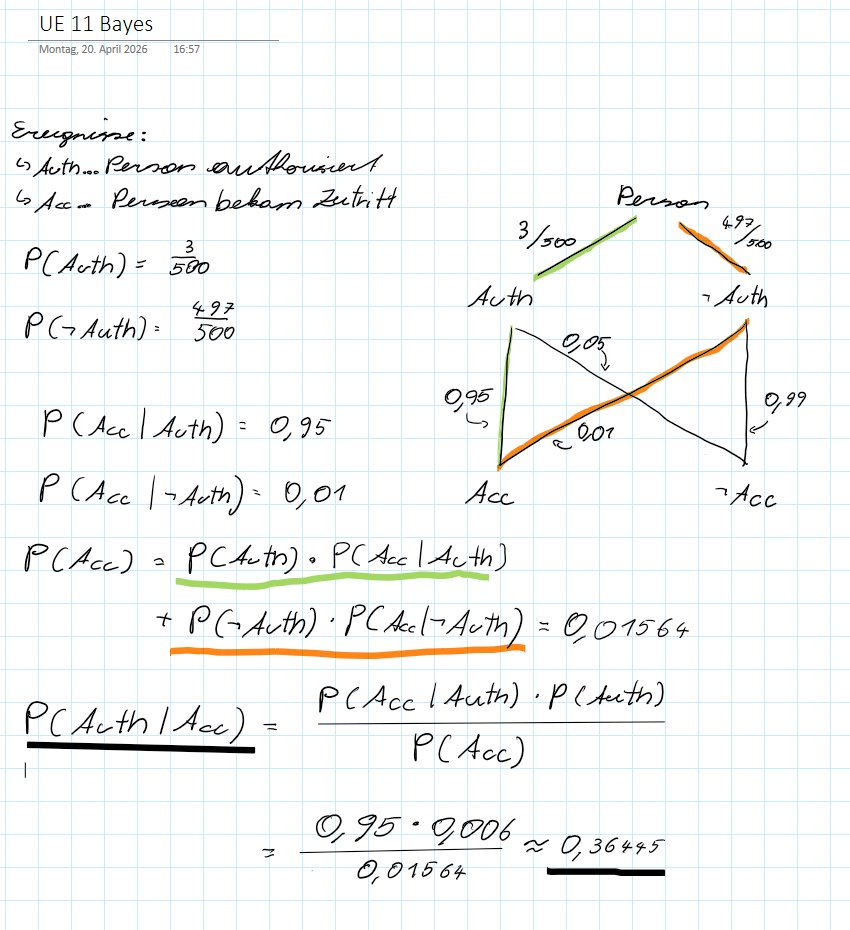



## Konfidenzintervall für einen Anteil
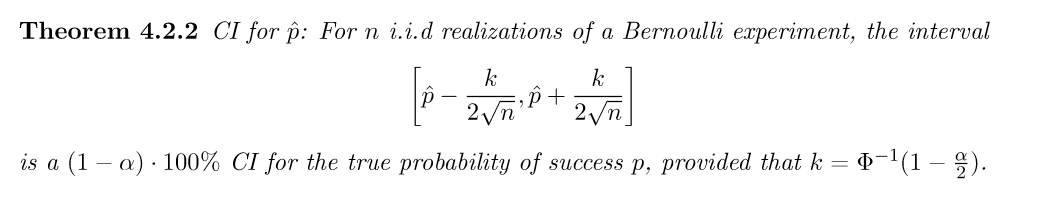
Die halbe Breite $\dfrac{k}{2\sqrt n}$ ist der **Worst Case** ($p(1-p)\le \tfrac14$),
hängt also nur von $n$ ab. Für $99\,\%$ ist $\alpha = 0{,}01$ und $k = \Phi^{-1}(0{,}995) \approx 2{,}5758$.


In [ ]:
import numpy as np
import random
from scipy import stats
import matplotlib.pyplot as plt
random.seed(42)

In [38]:
# Werte aus Aufgabe 11
# P(Auth)
P_auth = 3 / 500
# P(!Auth)
P_not_auth = 497 / 500
# P(Acc | Auth)
P_acc_g_auth = 0.95
# P(Acc | !Auth)
P_acc_g_notauth = 0.01

# satz von bayes
P_acc = P_auth * P_acc_g_auth + P_not_auth * P_acc_g_notauth # 0.01564
p_auth_given_acc = (P_acc_g_auth * P_auth) / P_acc # 0.3645

alpha = 0.01
k = stats.norm.ppf(1 - alpha / 2) #(z-Wert für 99%)

print(f"P(Acc) = {P_acc:.5f}")
print(f"p = P(Auth|Acc) = {p_auth_given_acc:.4f}")
print(f"k (99%) = {k:.4f}")

P(Acc) = 0.01564
p = P(Auth|Acc) = 0.3645
k (99%) = 2.5758


## Wie viele Zutritte (Trials) für 2 % Genauigkeit?

Wir verlangen, dass die halbe Breite des KI höchstens $l = 0{,}02$ ist, und lösen nach $n$ auf:
Halbe KI-Breite, wei

$$ \frac{k}{2\sqrt{n}} \le l \quad\Longrightarrow\quad n \ge \left(\frac{k}{2\,l}\right)^2 $$


In [33]:
l = 0.02 # gewünschte Genauigkeit (halbe Breite)

# Skript-Formel
n_needed = int(np.ceil((k / (2 * l))**2)) # aufrunden

print(f"benötigte Zutritte (konservativ): {n_needed}")

benötigte Zutritte (konservativ): 4147


## Wie viele Simulationen?

Ein "Zutritt" ist selten: nur $P(\text{Acc}) \approx 1{,}56\,\%$ aller Personen bekommen
überhaupt Zutritt. Um $n$ Zutritte (= Trials) zu sammeln, müssen wir also deutlich
mehr Personen simulieren:

$$ N_{\text{sim}} \approx \frac{n}{P(\text{Acc})}. $$


In [34]:
n_sim_needed = int(np.ceil(n_needed / P_acc))
print(f"benötigte Simulationen ≈ {n_needed} / {P_acc:.5f} = {n_sim_needed}")

benötigte Simulationen ≈ 4147 / 0.01188 = 349075


## Simulation (aus Aufgabe 11)

In [35]:
def simulate_access_control(num_trials):
    """Simuliert num_trials Personen. Gibt für jede Person MIT Zutritt (Acc)
    eine 1 zurück, falls sie autorisiert war, sonst 0."""
    outcomes = []
    for _ in range(num_trials):
        is_authorised = random.random() < (3 / 500) # P(Auth)
        if is_authorised:
            if random.random() < 0.95: # P(Acc | Auth)
                outcomes.append(1) # Zutritt UND autorisiert
        else:
            if random.random() < 0.01: # P(Acc | ¬Auth)
                outcomes.append(0) # Zutritt, NICHT autorisiert
    return outcomes

# etwas mehr als nötig für plot
num_trials = 300000
outcomes = np.array(simulate_access_control(num_trials))

n_access = len(outcomes) # anz Zutritte (= n in der Formel)
p_hat = outcomes.mean() # Schätzer für Bernoulli
half = k / (2 * np.sqrt(n_access)) # halbe KI-Breite

print(f"simulierte Personen: {num_trials}")
print(f"Zutritte (Trials): {n_access}")
print(f"p_hat = P(Auth|Acc): {p_hat:.4f} (analytisch {p_auth_given_acc:.4f})")
print(f"99% KI: [{p_hat - half:.4f}, {p_hat + half:.4f}]  (±{half:.4f})")


simulierte Personen: 300000
Zutritte (Trials): 4716
p_hat = P(Auth|Acc): 0.3617 (analytisch 0.1599)
99% KI: [0.3430, 0.3805]  (±0.0188)


## Band

Wir variieren die Anzahl der Trials $n = 1, 2, \dots$ und zeichnen den laufenden
Schätzer $\hat p$ samt KI-Band $\hat p \pm \dfrac{k}{2\sqrt n}$ auf

In [36]:
n = np.arange(1, n_access + 1)
print('n:', n)
p_run = np.cumsum(outcomes) / n # laufender Schätzer
print('p_run:', p_run)

# konfidenzband
band = k / (2 * np.sqrt(n)) # laufende halbe KI-Breite nach 4.2.2
lower = p_run - band
upper = p_run + band

n: [   1    2    3 ... 4714 4715 4716]
p_run: [0.         0.5        0.33333333 ... 0.36190072 0.36182397 0.36174724]


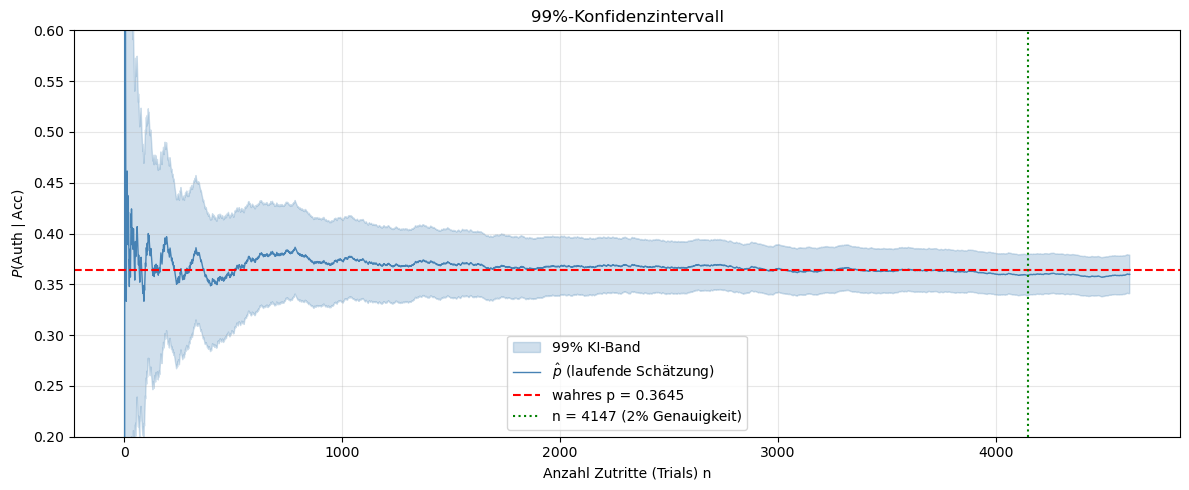

In [27]:
plt.figure(figsize=(12, 5))
plt.fill_between(n, lower, upper, alpha=0.25, color="steelblue", label="99% KI-Band")
plt.plot(n, p_run, lw=1, color="steelblue", label=r"$\hat p$ (laufende Schätzung)")
plt.axhline(p_auth_given_acc, color="red", ls="--", label=f"wahres p = {p_auth_given_acc:.4f}")
plt.axvline(n_needed, color="green", ls=":", label=f"n = {n_needed} (2% Genauigkeit)")
plt.xlabel("Anzahl Zutritte (Trials) n")
plt.ylabel(r"$P(\text{Auth} \mid \text{Acc})$")
plt.title("99%-Konfidenzintervall")
plt.ylim(0, 1)
plt.legend()
plt.ylim(0.2, 0.6)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Ergebnis

> - 99 % KI für p = P( Auth | Acc ) = ca. 0,3645 mit k = 2,5758.
> - Für +/- 2% Genauigkeit braucht man n = ca. 4147 Zutritte
> - Das entspricht ca. 265 000 Simulationen, da nur ein sehr geringer Anteil an Personen vom System zutritt bekommt
> - Das Band zeigt: je mehr Trials, desto enger das KI
